In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

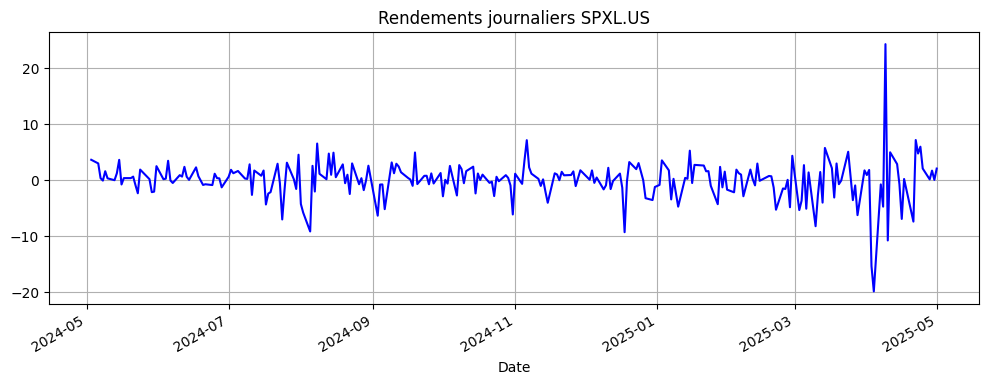

In [2]:
# Lecture des rendements depuis le CSV sauvegardé
df = pd.read_csv("../data/processed/spxl_returns.csv", parse_dates=["Date"], index_col="Date")

# Extraction de la série de rendements
returns = df["log_returns"] * 100  # GARCH préfère les rendements en pourcentage
returns.plot(figsize=(12, 4), title="Rendements journaliers SPXL.US", color="blue")
plt.grid(True)
plt.show()


In [3]:
# Création du modèle GARCH(1,1)
model = arch_model(returns, vol='GARCH', p=1, q=1)

# Entraînement
model_fit = model.fit(disp="off")
print(model_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -621.689
Distribution:                  Normal   AIC:                           1251.38
Method:            Maximum Likelihood   BIC:                           1265.45
                                        No. Observations:                  249
Date:                Fri, May 02 2025   Df Residuals:                      248
Time:                        18:05:11   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2013      0.156      1.291      0.197 [ -0.104,  0.50

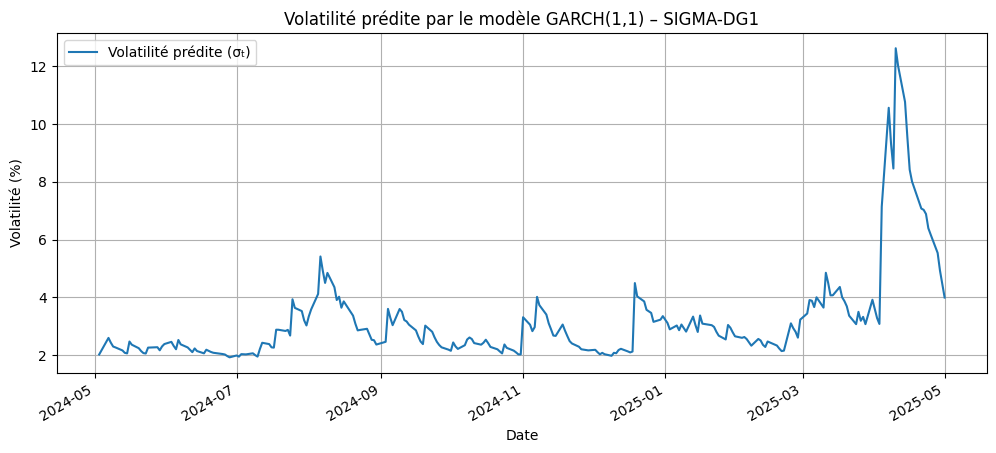

In [4]:
# Volatilité conditionnelle (sigma_t)
df["predicted_volatility"] = model_fit.conditional_volatility

# Visualisation
plt.figure(figsize=(12, 5))
df["predicted_volatility"].plot(label="Volatilité prédite (σₜ)")
plt.title("Volatilité prédite par le modèle GARCH(1,1) – SIGMA-DG1")
plt.xlabel("Date")
plt.ylabel("Volatilité (%)")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
# Utiliser la volatilité comme approximation de |rendement|
true_vol = df["log_returns"].abs()
pred_vol = df["predicted_volatility"]

# MAE et RMSE
mae = mean_absolute_error(true_vol, pred_vol)
rmse = np.sqrt(mean_squared_error(true_vol, pred_vol))

print(f" MAE (erreur absolue moyenne) : {mae:.4f}")
print(f" RMSE (erreur quadratique moyenne) : {rmse:.4f}")

 MAE (erreur absolue moyenne) : 3.1576
 RMSE (erreur quadratique moyenne) : 3.5539


In [7]:
# Sauvegarder les données avec les prédictions de volatilité
df.to_csv("../data/processed/spxl_volatility_garch.csv")
print(" Résultats GARCH sauvegardés dans data/processed/spxl_volatility_garch.csv")


 Résultats GARCH sauvegardés dans data/processed/spxl_volatility_garch.csv
